# 06 — Embedding similarity (proposal 3.3.6) → RQ2

In [1]:
%load_ext autoreload
%autoreload 2

import sys, pathlib
sys.path.append(str(pathlib.Path.cwd().parent))  # so `import src...` works from notebooks/

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src import config
from src.utils import set_seed, save_fig
set_seed()  # fix all RNGs -- reproducibility

Reuse cached SBERT embeddings. Centroids → cosine → Ward dendrogram (confusion/lineage
half of RQ2). Domain-wise LLM→human distances (human-likeness half of RQ2).

In [2]:
from src import data, features, analysis, viz
clean = data.load_or_build_clean()
emb = features.build_sbert(clean['text'])   # cached
y = clean[config.LABEL_COL].values

In [3]:
cents = analysis.class_centroids(emb, y)
sim = analysis.centroid_cosine_matrix(cents)
link = analysis.ward_dendrogram_linkage(cents)
sim

,human,chatgpt,gpt4,gpt3,gpt2,llama-chat,mistral,mistral-chat,mpt,mpt-chat,cohere,cohere-chat
human,1.000000,0.863553,0.875225,0.860713,0.586572,0.884414,0.765107,0.852983,0.769882,0.845637,0.963475,0.909465
chatgpt,0.863553,1.000000,0.982161,0.877158,0.577354,0.966822,0.730940,0.983564,0.746970,0.968075,0.922267,0.955635
gpt4,0.875225,0.982161,1.000000,0.870279,0.596874,0.957478,0.753935,0.963478,0.771784,0.941528,0.930836,0.944407
gpt3,0.860713,0.877158,0.870279,1.000000,0.631129,0.860695,0.786793,0.908227,0.793655,0.932968,0.939925,0.953713
gpt2,0.586572,0.577354,0.596874,0.631129,1.000000,0.590740,0.943159,0.616693,0.940650,0.572734,0.618939,0.609897
llama-chat,0.884414,0.966822,0.957478,0.860695,0.590740,1.000000,0.749486,0.960813,0.765179,0.934798,0.929233,0.950792
mistral,0.765107,0.730940,0.753935,0.786793,0.943159,0.749486,1.000000,0.762813,0.990681,0.719706,0.797650,0.772797
mistral-chat,0.852983,0.983564,0.963478,0.908227,0.616693,0.960813,0.762813,1.000000,0.779384,0.981133,0.926872,0.968022
mpt,0.769882,0.746970,0.771784,0.793655,0.940650,0.765179,0.990681,0.779384,1.000000,0.733950,0.808390,0.784605
mpt-chat,0.845637,0.968075,0.941528,0.932968,0.572734,0.934798,0.719706,0.981133,0.733950,1.000000,0.923179,0.975714


PosixPath('/Users/xinye/Desktop/module 3/5 nautral language proccesing/syndicate asm/llm-source-attribution/figures/centroid_cosine_heatmap.png')

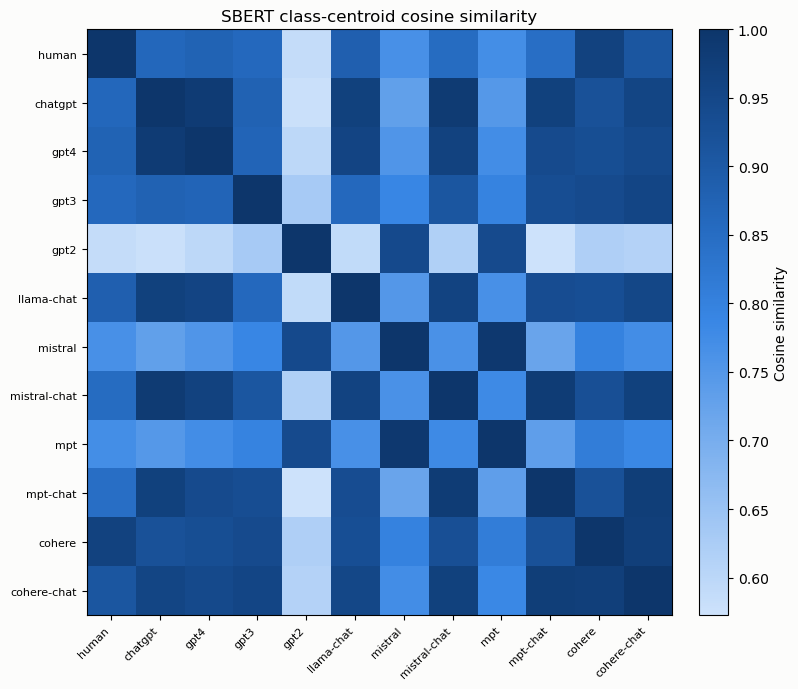

In [4]:
labels = list(cents.keys())

fig, ax = plt.subplots(figsize=(8, 7), facecolor=viz.SURFACE)
im = ax.imshow(sim.values, cmap=viz.SEQUENTIAL_BLUE, vmin=sim.values[~np.eye(len(labels), dtype=bool)].min(), vmax=1)
ax.set_xticks(range(len(labels))); ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=8)
ax.set_yticks(range(len(labels))); ax.set_yticklabels(labels, fontsize=8)
ax.set_title('SBERT class-centroid cosine similarity')
cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label('Cosine similarity')
fig.tight_layout()
save_fig(fig, 'centroid_cosine_heatmap')

PosixPath('/Users/xinye/Desktop/module 3/5 nautral language proccesing/syndicate asm/llm-source-attribution/figures/centroid_dendrogram.png')

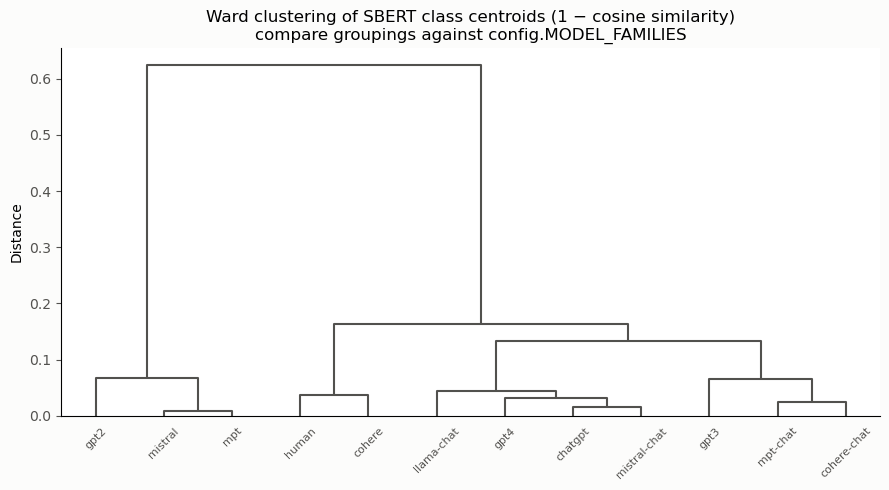

In [5]:
from scipy.cluster.hierarchy import dendrogram

fig, ax = plt.subplots(figsize=(9, 5), facecolor=viz.SURFACE)
dendrogram(link, labels=labels, ax=ax, color_threshold=0, above_threshold_color=viz.INK_SECONDARY)
ax.set_title('Ward clustering of SBERT class centroids (1 − cosine similarity)\ncompare groupings against config.MODEL_FAMILIES')
ax.set_ylabel('Distance')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(axis='x', labelrotation=45, labelsize=8, colors=viz.INK_SECONDARY)
ax.tick_params(axis='y', colors=viz.INK_SECONDARY)
fig.tight_layout()
save_fig(fig, 'centroid_dendrogram')

In [6]:
dom = analysis.domain_human_distances(emb, clean)
dom   # sorted ascending -- top rows are the LLMs closest to human writing

,mean_distance,std_distance,n_domains
model,,,
cohere,0.031807,0.014779,8.0
cohere-chat,0.064682,0.032228,8.0
gpt3,0.099064,0.057028,8.0
llama-chat,0.105144,0.048062,8.0
gpt4,0.109650,0.043542,8.0
mistral-chat,0.116524,0.050499,8.0
chatgpt,0.128411,0.074091,8.0
mpt-chat,0.130719,0.063413,8.0
mpt,0.182225,0.095721,8.0


In [ ]:
# Single-series ranked chart -- one hue (magnitude, not category identity),
# error bars carry each LLM's domain-to-domain variability (RQ2).
dom_sorted = dom.sort_values('mean_distance', ascending=True)

fig, ax = viz.new_fig(figsize=(7, 6))
y_pos = np.arange(len(dom_sorted))
ax.barh(y_pos, dom_sorted['mean_distance'], xerr=dom_sorted['std_distance'],
        color=viz.SEQUENTIAL_BLUE(0.6), ecolor=viz.INK_MUTED, capsize=3, zorder=3)
ax.set_yticks(y_pos)
ax.set_yticklabels(dom_sorted.index)
ax.set_xlabel('Mean cosine distance to within-domain human centroid')
ax.set_title('LLM → human semantic distance, averaged across 8 domains\n(shorter bar = more human-like writing; error bar = domain variability)')
fig.tight_layout()
save_fig(fig, 'domain_human_distance')

### Conclusion (RQ2)

**Confirms `05_error_analysis`'s finding via a completely independent
method** (embedding geometry instead of classifier confusion patterns) —
strong cross-validation, not a coincidence:

- **`gpt2` is the clear semantic outlier.** Its centroid has visibly lower
  cosine similarity to every other class (~0.60–0.70 vs ~0.85–0.95+ among
  everyone else), and `{gpt2, mistral, mpt}` split off from the rest of the
  dendrogram at distance 0.62 — the same base-vs-chat-tuned split found in
  05's confusion-pattern clustering, this time from embedding geometry
  alone. Most sources are semantically close to each other in SBERT space
  (expected: they're all answering the same prompts), which is also why
  SBERT-only was a weak attribution feature in `02_features`.
- **`cohere` is the most human-like model, consistently** — ranked #1 by
  domain-averaged distance to the human centroid (0.032, smallest of all 11),
  *and* has the smallest error bar (most stable across domains), *and* pairs
  tightest with `human` in the dendrogram (0.037). Three separate readings
  of the same signal agree.
- **`gpt2` is both the least human-like and the least *consistently*
  so** — largest mean distance (0.345) *and* by far the largest domain-to-
  domain error bar. For gpt2, human-likeness (or the lack of it) is unstable
  across domains; for cohere, it's stable. (Domain variation itself gets a
  proper full treatment in `07_domain`, RQ3.)
- **Chat-tuning consistently closes the gap to human writing**, within every
  family that has both variants: mistral 0.19 → mistral-chat 0.12, mpt 0.18
  → mpt-chat 0.13. Quantitative evidence for the qualitative "alignment
  status, not lineage" story from `05_error_analysis`.

Net: two independent analyses (classifier confusion vs. embedding distance)
triangulate to the same conclusions for RQ2 — safe to report both as mutually
reinforcing, not redundant.